정렬(Sorting)은 이진 탐색(Binary Search)과 그리디(Greedy) 알고리즘의 전제 조건   
-> 어떤 상황에서 어떤 정렬을 써야 하는지 이해하는 것이 중요 

정렬의 중요성 
- 데이터의 효율적 탐색: 정렬이 되어 있어야 이진 탐색이 가능
- 효율적인 문제 해결: 가장 큰/작은 값을 빠르게 찾거나, 중복을 제거하는 데 필수적

시간 복잡도에 따른 분류 
- O(N^2) -> 구현이 쉽지만 데이터가 10만 개만 넘어가도 시간 초과(Time Limit)가 발생한다.    
         -> N이 매우 작거나(약 1,000 이하), 이미 거의 정렬된 상태일 때(삽입 정렬) 사용하면 좋다. 
    1. 버블 bubble : 데이터의 인접 요소끼리 비교하고, swap 연산을 수행하며 정렬하는 방식 
    2. 선택 selection : 대상에서 가장 크거나 작은 데이터를 찾아 선택하는 과정을 반복하면서 정렬하는 방식 
    3. 삽입 insertion : 대상을 선택해 정렬된 영역에서 선택 데이터의 적절한 위치를 찾아 삽입하는 방식 

- O(N log N) 알고리즘 (코테의 표준) -> 데이터가 많아도(10만~100만 개) 빠르게 수행한다.        
    4. 퀵 quick : pivot 값을 선정해 해당 값을 기준으로 정렬하는 방식      
    5. 병합 merge : 이미 정렬된 부분 집합들을 효율적으로 병합해 전체를 정렬하는 방식        

- O(N) 알고리즘 (특수 상황. 비교 연산을 하지 않음) -> 데이터의 범위가 제한적일 때만 사용 가능(예: 모든 데이터가 0 이상 100 이하의 정수일 때)        
    6. 기수 radix : 데이터의 자릿수를 바탕으로 비교해 데이터를 정렬하는 방식     
     -> 실제로 문제를 풀 때는 직접 구현하기보다 내장 라이브러리 sort()를 쓰는게 낫지만, 기수 정렬만큼은 직접 구현해야 할 때가 있음.



[Python의 특징]
- sort() = 삽입정렬 + 병합정렬 -> Timsort -> O(n log n) 이므로 웬만한 정렬문제는 구현하지 말고 sort() 쓰면됨. 단 범위가 좁다면 계수 정렬이 필살기가 될수도 있음. 
- lambda -> arr.sort(key=lambda x: (x[0], -x[1])) -> 좌표 정렬을 한줄로 끝낼 수 있음 
- swap 이 쉽다 -> a, b = b, a 

우리가 책에서 6개 알고리즘을 공부했지만, 코딩테스트 시 직접 def를 선언해서 짜야 할 알고리즘은 계수정렬밖에 없습니다. 
- 버블/선택 정렬은 너무 느려서 실전에서 쓸 일이 없고, 
- 퀵 정렬은 재귀함수의 한계와 시간 초과 위험 때문에 sort가 무조건 더 좋고, 
- 삽입 정렬은 정렬 자체보다는 실시간으로 데이터가 들어올 때마다 순위를 매겨야 하는 경우에 로직만 종종 쓰인다고 합니다. 
- 병합 정렬은 정렬 결과가 중요한 게 아니라, 정렬 '과정'이 중요할 때 응용되는데, 예를 들면 <버블 정렬을 할 때 Swap이 총 몇 번 일어나는가> 같은 문제에 쓰입니다.     
- 기수 정렬은 정렬 자체보다는 숫자를 세어야 할 때 쓰입니다. 데이터 개수(N)는 엄청 많은데(100만 이상), 데이터의 범위(값의 크기)가 작을 때 필요합니다.     
따라서 6개 문제 중에, 삽입 정렬, 병합 정렬, 기수 정렬 위주로 설명드리겠습니다. 

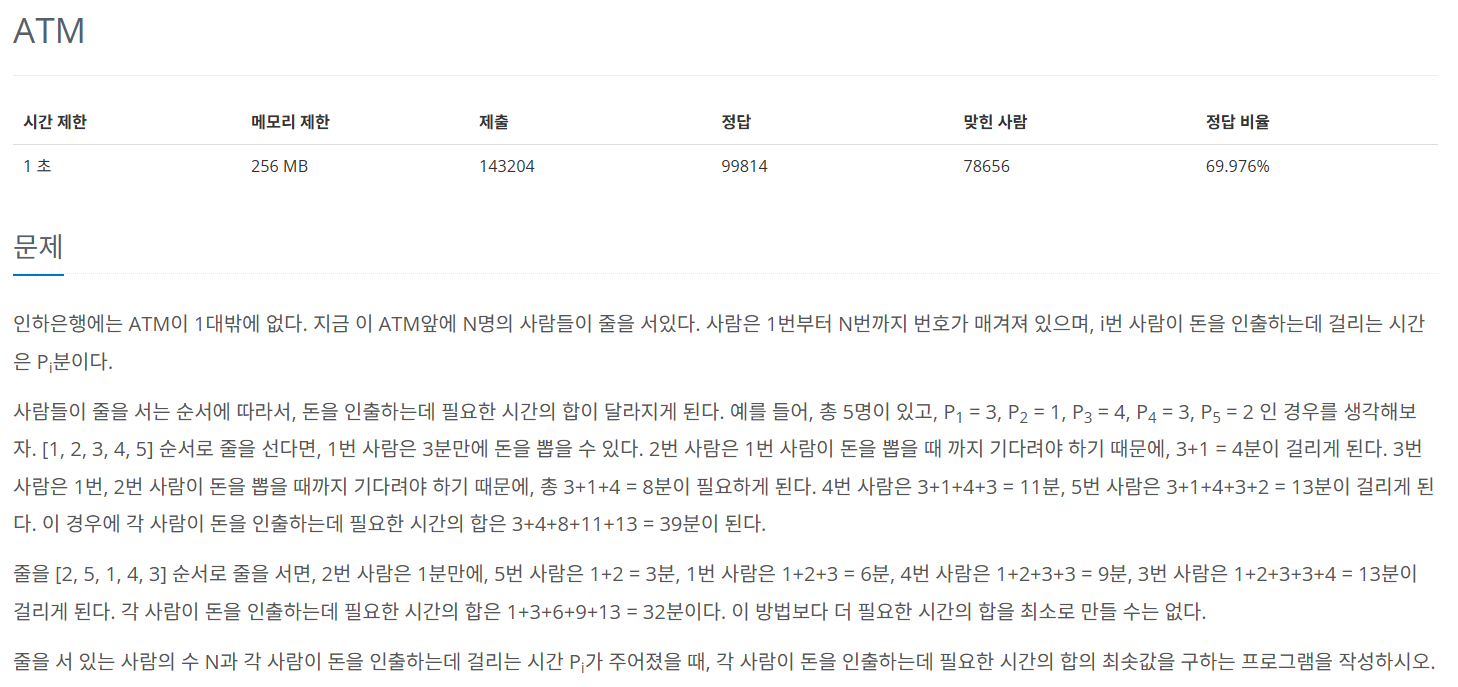

In [7]:
from IPython.display import Image, display
image_path = "C:/Users/user/Desktop/img.png"
display(Image(filename=image_path))

In [ ]:
#삽입 정렬_ATM 인출 시간 계산하기 (실제로는 그리디 알고리즘과 유사)
#앞사람의 소요 시간이 뒷사람에게 누적된다는 점을 이용하여, 오름차순 정렬을 통해 전체 대기 시간의 합을 최소화하는 문제
#입력: 첫째 줄에 사람의 수 N(1 ≤ N ≤ 1,000), 둘째 줄에는 각 사람이 돈을 인출하는데 걸리는 시간 Pi(1 ≤ Pi ≤ 1,000)
#출력: 첫째 줄에 각 사람이 돈을 인출하는데 필요한 시간의 합의 최솟값을 출력한다. 

import sys
input = sys.stdin.readline

N = int(input())
P = list(map(int, input().split()))

# 두 번째 부터 시작해서 앞의 것들과 비교
for i in range(1, N):
    key = P[i]  # 현재 정렬하려는 값
    j = i - 1   # 내 바로 앞 위치
    
    # 나(key)보다 큰 앞사람들은 뒤로 한 칸씩 밀어냄
    while j >= 0 and P[j] > key:
        P[j + 1] = P[j]
        j -= 1
    
    # 밀어내기가 끝나고 빈 자리에 쏙 들어감
    P[j + 1] = key

# 정렬된 P를 이용해 누적 합 계산
total_sum = 0
current_waiting = 0

for time in P:
    current_waiting += time
    total_sum += current_waiting

print(total_sum)


In [ ]:
# sort()를 써서 간편하게 구현할 때 
#이 문제는 삽입 정렬의 '원리'를 배우는 단원이지만, 실전 풀이는 오름차순 정렬 후 누적 합을 구하는 것이 핵심
import sys

# 1. 입력 속도 최적화
input = sys.stdin.readline

N = int(input())
P = list(map(int, input().split()))

# 2. 핵심: 오름차순 정렬 (적게 걸리는 사람이 앞에 서야 함)
# 파이썬의 sort는 O(N log N)으로 삽입 정렬(O(N^2))보다 빠릅니다.
P.sort()

total_sum = 0
current_waiting = 0

# 3. 누적 대기 시간 계산
for time in P:
    current_waiting += time  # 내 대기 시간 = 이전 대기 시간 + 내 업무 시간
    total_sum += current_waiting # 전체 사람들의 시간 합에 더하기

print(total_sum)

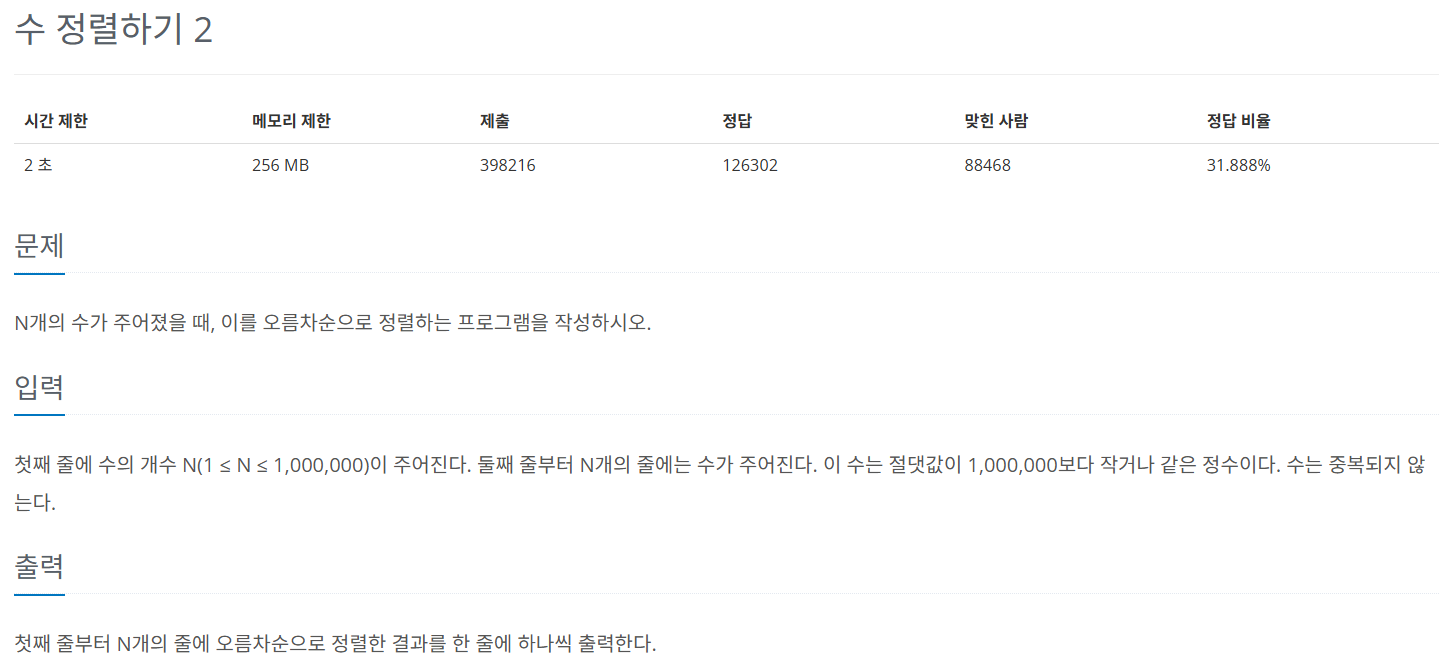

In [8]:
image_path_2 = "C:/Users/user/Desktop/img_2.png"
display(Image(filename=image_path_2))

In [ ]:
#병합 정렬
#N개의 수가 주어졌을 때, 이를 오름차순으로 정렬하는 프로그램을 작성하시오.
#입력: 첫째 줄에 수의 개수 N(1≤N≤1,000,000), 둘째 줄부터 N개의 줄에는 수가 주어진다. 이 수는 절댓값이 1,000,000보다 작거나 같은 정수이다. 수는 중복되지 않는다.
#출력: 첫째 줄부터 N개의 줄에 오름차순으로 정렬한 결과를 한 줄에 하나씩 출력한다.

import sys
input = sys.stdin.readline

def merge_sort(arr):
    # 1. Base Condition: 리스트가 1개 이하면 이미 정렬된 상태
    if len(arr) <= 1:
        return arr
    
    # 2. Divide: 허리(mid)를 끊어서 반으로 나눔
    mid = len(arr) // 2
    left_arr = merge_sort(arr[:mid])
    right_arr = merge_sort(arr[mid:])
    
    # 3. Conquer & Merge: 나뉜 두 리스트를 정렬하며 합침
    return merge(left_arr, right_arr)

def merge(left, right):
    result = []
    i = 0 # 왼쪽 리스트 인덱스
    j = 0 # 오른쪽 리스트 인덱스
    
    # 두 그룹을 비교하며 작은 순서대로 result에 담기
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    
    # 남은 데이터 털어 넣기 (비교할 대상이 없는 경우)
    result.extend(left[i:])
    result.extend(right[j:])
    
    return result

N = int(input())
arr = []
for _ in range(N):
    arr.append(int(input()))

# 직접 만든 함수 호출
sorted_arr = merge_sort(arr)

print(*arr)

In [ ]:
#sort를 쓰는 버전
import sys
input = sys.stdin.readline

# 1. 데이터 개수 100만 개 -> 빠른 입출력 필수
N = int(input())
arr = []

for _ in range(N):
    arr.append(int(input()))

# 2. 병합 정렬 기반의 Timsort 사용 (O(N log N) 보장)
arr.sort()

# 3. 출력 최적화: 반복문 print()는 느리므로 한 번에 출력하거나 형식을 맞춤
print(*arr)

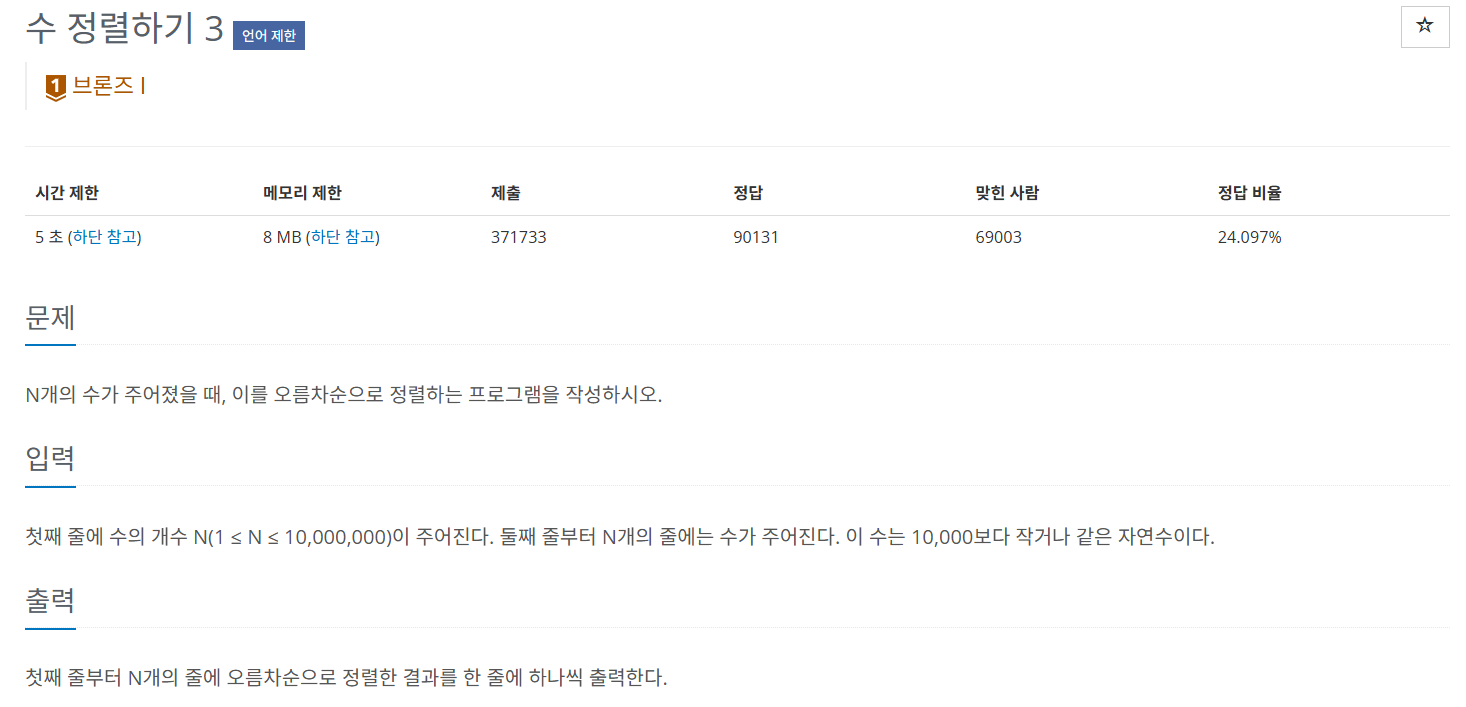

In [9]:
image_path_3 = "C:/Users/user/Desktop/img_3.png"
display(Image(filename=image_path_3))

In [ ]:
#기수 정렬
#N개의 수가 주어졌을 때, 이를 오름차순으로 정렬하는 프로그램을 작성하시오.
#입력: 첫째 줄에 수의 개수 N(1 ≤ N ≤ 10,000,000)이 주어진다. 둘째 줄부터 N개의 줄에는 수가 주어진다. 이 수는 10,000보다 작거나 같은 자연수이다.
#출력: 첫째 줄부터 N개의 줄에 오름차순으로 정렬한 결과를 한 줄에 하나씩 출력한다.

#이 문제가 가장 중요
#메모리 제한(8MB) 때문에 일반적인 정렬(append -> sort)을 하면 메모리 초과로 실패

import sys
input = sys.stdin.readline

N = int(input())

# 1. 메모리 초과 방지: 
# 데이터를 리스트에 다 저장하지 않고, 숫자 범위(10,000)만큼의 카운팅 배열만 만듭니다.
# index 0은 안 쓰거나 0을 위해 비워둠 (문제는 자연수라면 1~10000)
count = [0] * 10001 

# 2. 숫자 세기 (Counting)
# 입력받는 즉시 해당 숫자의 개수만 +1 하고, 숫자는 저장하지 않고 날립니다.
for _ in range(N):
    num = int(input())
    count[num] += 1

# 3. 정렬 결과 출력
# 0부터 10000까지, 기록된 개수만큼 반복 출력
for i in range(10001):
    if count[i] != 0:
        for _ in range(count[i]):
            print(i)